In [5]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# Define model parameters
r1 = 0.5  # Growth rate of crops
r2 = 0.3  # Growth rate of pests
r3 = 0.2  # Growth rate of beneficial insects
K_P = 1000  # Carrying capacity of crops
w1 = 0.1  # Effect of pests on crops
w2 = 0.2  # Carrying capacity for pests supported by crops
w3 = 0.3  # Carrying capacity for beneficial insects supported by pests
beta = 0.1  # Impact of beneficial insects on pests
C_w1 = 0.05  # Impact of pesticide on crop growth
C_w2 = 0.1  # Impact of pesticide on pests
G = 0.85  # Harvest disturbance rate
C0 = 1.0  # Initial concentration of pesticide
k = 0.1  # Decay rate of pesticide
T = 1.0  # Time interval per quarter
crop_price = 10.0  # Price per unit of crop
pesticide_unit_cost = 2.0  # Cost per unit of pesticide (renamed to avoid conflict)
w1_env = 0.5  # Weight for soil fertility in environmental objective
w2_env = 0.5  # Weight for biodiversity in environmental objective

# Define the system dynamics
def system_dynamics(t, y, x):
    P, H, B = y
    C = sum(x_i * C0 * np.exp(-k * (t - i * T)) for i, x_i in enumerate(x) if t >= i * T)
    
    dP_dt = (r1 / (1 + (C_w1 * C)**2)) * (P * (1 - P / K_P) - w1 * H * P - G * P)
    dH_dt = r2 * H * (1 - H / (w2 * P)) - beta * B * H - C_w2 * C * H
    dB_dt = r3 * B * (1 - B / (w3 * H))
    
    return [dP_dt, dH_dt, dB_dt]

# Define the objective function
def objective_function(x):
    sol = solve_ivp(system_dynamics, [0, 16], [50, 10, 5], args=(x,), t_eval=np.arange(0, 17))
    P = sol.y[0]
    H = sol.y[1]
    B = sol.y[2]
    
    # Economic objective (Harvest Revenue - Pesticide Cost)
    harvest_revenue = 0.85 * np.sum(P[::4]) * crop_price
    total_pesticide_cost = np.sum(x) * pesticide_unit_cost  # Use the renamed variable
    F1 = harvest_revenue - total_pesticide_cost
    
    # Normalize Economic Objective (F1)
    max_harvest_revenue = crop_price * 0.85 * np.sum(P)  # Maximum if all crops grew perfectly
    F1_normalized = F1 / max_harvest_revenue
    
    # Environmental objective (Soil Fertility + Biodiversity)
    S_n = 1 / (1 + 0.1 * np.sum(x))  # Simplified soil fertility index
    p_P = P / (P + H + B)
    p_H = H / (P + H + B)
    p_B = B / (P + H + B)
    H_n = -np.sum([p_P * np.log(p_P), p_H * np.log(p_H), p_B * np.log(p_B)])
    
    # Normalize Environmental Objective (F2)
    max_S_n = 1  # Maximum soil fertility is 1
    max_H_n = np.log(3)  # Maximum entropy, when all populations are equal
    F2_normalized = w1_env * (S_n / max_S_n) + w2_env * (H_n / max_H_n)
    
    # Combine objectives (minimize -F1_normalized and -F2_normalized)
    return -F1_normalized, -F2_normalized

# Define a combined objective for single-objective optimization
def combined_objective(x):
    F1, F2 = objective_function(x)
    return F1 + F2  # Combine objectives (you can adjust weights)

# New initial guess for pesticide input (starting with moderate pesticide use)
x0 = [4,5,2,3,2,3,2,2,2,2,2,2,2,2,2,2]  # Start with pesticide input of 1 unit for each time step

# Run the optimization allowing pesticide use (bounds from 0 to 3)
result = minimize(combined_objective, x0, bounds=[(0, 3)] * 16, method='L-BFGS-B')

# Print the results
print("Optimal pesticide input:")
print(result.x)
print("Objective values:")
print(-result.fun)

Optimal pesticide input:
[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.81745823e-03
 1.48996402e-03 1.91385557e+00 1.20290667e+00 1.27131225e+00
 1.62081782e+00 1.70553964e+00 1.76704253e+00 1.80220395e+00
 1.84381550e+00 1.83629865e+00 1.85088602e+00 1.85293374e+00]
Objective values:
3.3968604213629816


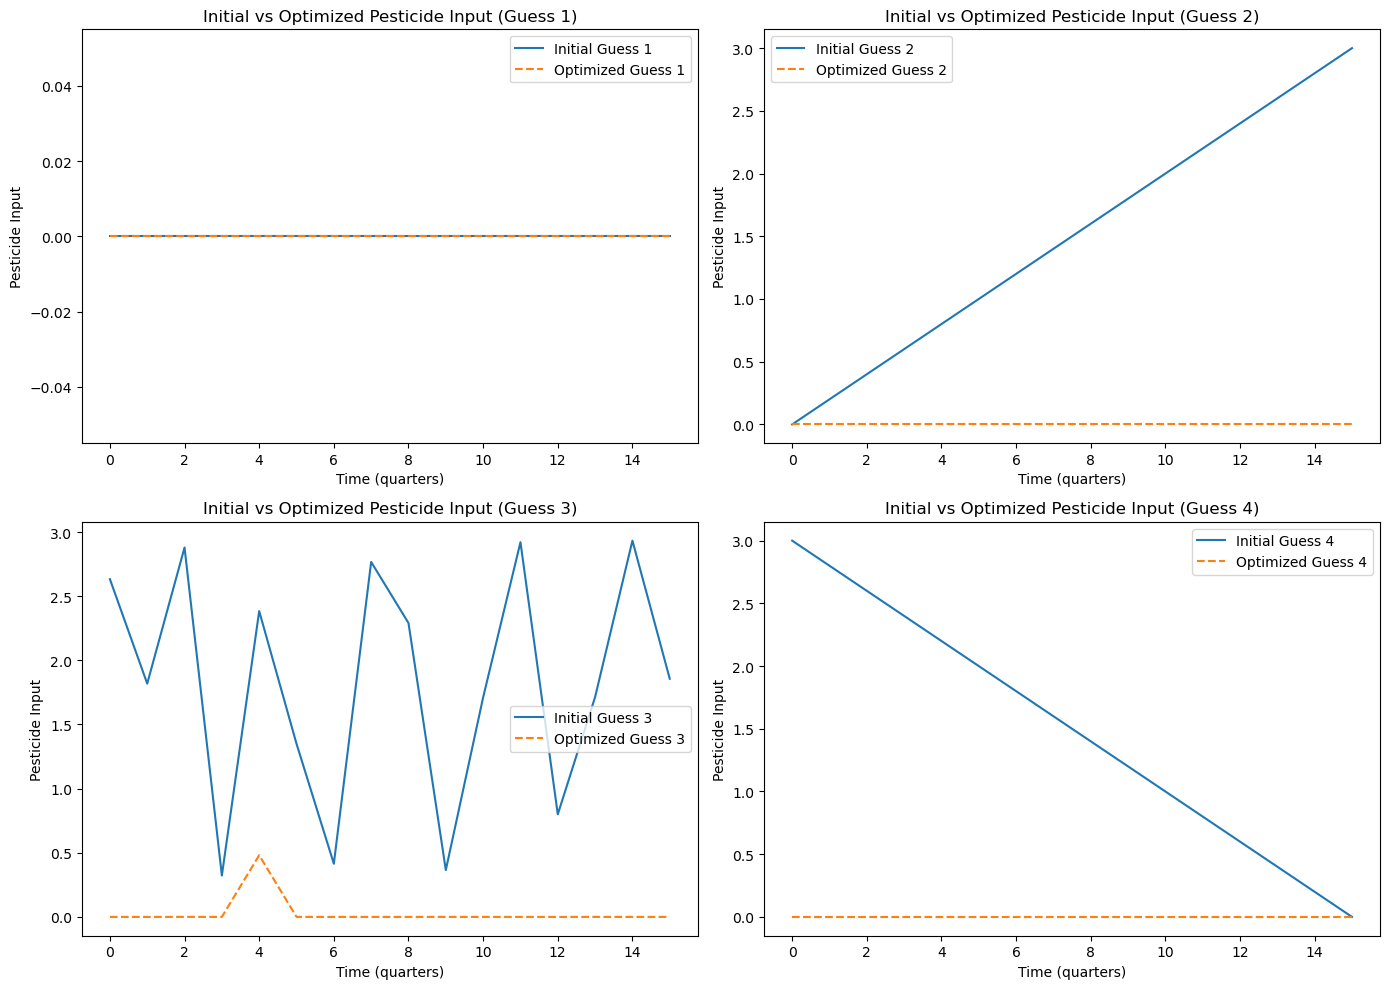

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# Define model parameters
r1, r2, r3 = 0.5, 0.3, 0.2  # Growth rates
K_P = 100  # Carrying capacity of crops
w1, w2, w3 = 0.1, 0.2, 0.3  # Interaction coefficients
beta, C_w1, C_w2 = 0.1, 0.05, 0.1  # Pesticide effects
G, C0, k = 0.85, 1.0, 0.1  # Harvest disturbance rate, pesticide concentration, decay
T = 1.0  # Time interval per quarter
crop_price, pesticide_unit_cost = 10.0, 2.0  # Costs
w1_env, w2_env = 0.5, 0.5  # Environmental weights

# Define system dynamics
def system_dynamics(t, y, x):
    P, H, B = y
    C = sum(x_i * C0 * np.exp(-k * (t - i * T)) for i, x_i in enumerate(x) if t >= i * T)
    dP_dt = (r1 / (1 + (C_w1 * C)**2)) * (P * (1 - P / K_P) - w1 * H * P - G * P)
    dH_dt = r2 * H * (1 - H / (w2 * P)) - beta * B * H - C_w2 * C * H
    dB_dt = r3 * B * (1 - B / (w3 * H))
    return [dP_dt, dH_dt, dB_dt]

# Define objective function
def objective_function(x):
    sol = solve_ivp(system_dynamics, [0, 16], [50, 10, 5], args=(x,), t_eval=np.arange(0, 17))
    P, H, B = sol.y
    
    # Economic objective
    harvest_revenue = 0.85 * np.sum(P[::4]) * crop_price
    total_pesticide_cost = np.sum(x) * pesticide_unit_cost
    F1 = harvest_revenue - total_pesticide_cost
    
    # Min-Max Normalization for F1
    min_harvest_revenue = 0  # 假设最小可能收入为 0
    max_harvest_revenue = crop_price * 0.85 * np.sum(P)  # 最大可能收入

    # 确保 denominator 不为 0
    if max_harvest_revenue > min_harvest_revenue:
        F1_normalized = (F1 - min_harvest_revenue) / (max_harvest_revenue - min_harvest_revenue)
        F1_normalized = np.clip(F1_normalized, 0, 1)  # 确保范围在 [0, 1]
    else:
        F1_normalized = 0  # 如果没有有效的归一化范围
    # Environmental objective
    S_n = 1 / (1 + 0.1 * np.sum(x))  # Soil fertility index
    p_P, p_H, p_B = P / (P + H + B), H / (P + H + B), B / (P + H + B)
    
    # Avoid log of zero or negative values
    p_P = np.clip(p_P, 1e-10, 1)
    p_H = np.clip(p_H, 1e-10, 1)
    p_B = np.clip(p_B, 1e-10, 1)

    H_n = -np.nansum([p_P * np.log(p_P), p_H * np.log(p_H), p_B * np.log(p_B)])  # Handle NaNs
    max_H_n = np.log(3)
    F2_normalized = w1_env * (S_n / 1) + w2_env * (H_n / max_H_n)
    F2_normalized = np.clip(F2_normalized, 0, 1)  # Ensure within [0, 1]
    
    return -F1_normalized, -F2_normalized

# Combine objectives
def combined_objective(x):
    F1, F2 = objective_function(x)
    return F1 + F2  # Minimize the negative combined objective

# Initial guesses and bounds
initial_guesses = [
    np.zeros(16),  # No pesticide usage
    np.linspace(0, 3, 16),  # Increasing pesticide usage
    np.random.uniform(0, 3, 16),  # Random pesticide usage
    np.linspace(3, 0, 16),  # Decreasing pesticide usage
]

bounds = [(0, 3)] * 16

# Perform optimization for each initial guess
results = []
for x0 in initial_guesses:
    result = minimize(combined_objective, x0, bounds=bounds, method='L-BFGS-B')
    results.append(result)  # Save optimization results

# Plotting function to visualize the results
def plot_initial_vs_optimized(initial_guesses, results):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for i, (x0, result) in enumerate(zip(initial_guesses, results)):
        ax = axes[i // 2, i % 2]  # Determine the appropriate subplot

        ax.plot(x0, label=f'Initial Guess {i+1}')
        ax.plot(result.x, label=f'Optimized Guess {i+1}', linestyle='--')

        ax.set_title(f"Initial vs Optimized Pesticide Input (Guess {i+1})")
        ax.set_xlabel("Time (quarters)")
        ax.set_ylabel("Pesticide Input")
        ax.legend()

    plt.tight_layout()
    plt.show()

# Plot initial vs optimized results for each initial guess
plot_initial_vs_optimized(initial_guesses, results)

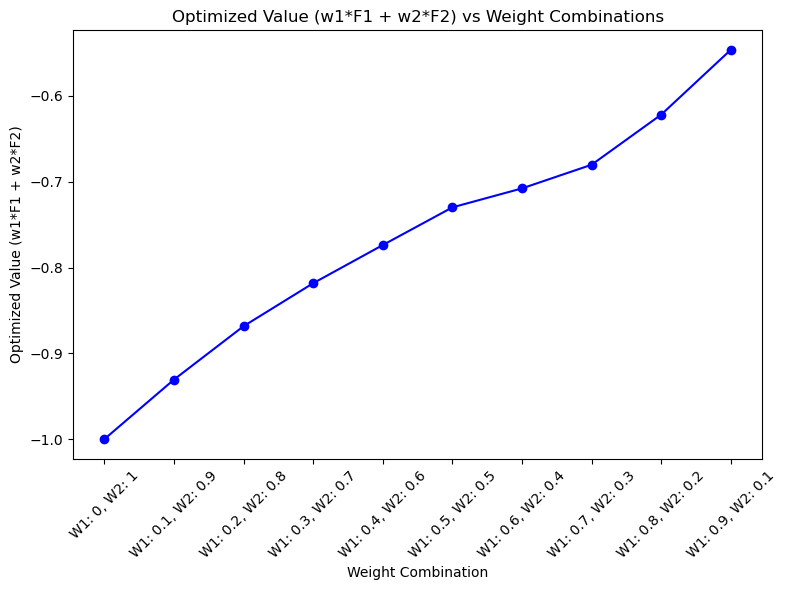

In [32]:
# Plot F1 + F2 vs weight combination
weight_combinations = [(0, 1), (0.1, 0.9), (0.2, 0.8), (0.3, 0.7), (0.4, 0.6), (0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (0.8, 0.2), (0.9, 0.1)]
optimized_values = []

# Define a weighted sum objective function
def weighted_sum_objective(x, w1, w2):
    F1, F2 = objective_function(x)  # Returns normalized F1 and F2
    return -(w1 * F1 + w2 * F2)  # Negative for maximization

# # Re-run optimization for each weight combination
# for w1, w2 in weight_combinations:
#     result = minimize(weighted_sum_objective, np.zeros(16), args=(w1, w2), bounds=[(0, 3)] * 16, method='L-BFGS-B')
#     optimized_values.append(-result.fun)  # Store the optimized value (we negate the result to match maximization)
for w1, w2 in weight_combinations:
    try:
        result = minimize(weighted_sum_objective, np.ones(16) * 1.5, args=(w1, w2), bounds=[(0, 3)] * 16, method='L-BFGS-B')
        optimized_values.append(-result.fun)  # Store the optimized value (we negate the result to match maximization)
    except Exception as e:
        print(f"Optimization failed for weights ({w1}, {w2}): {e}")
        optimized_values.append(None)  # Use None for failed cases

# Plot optimized values vs weight combinations
weight_labels = [f'W1: {w1}, W2: {w2}' for w1, w2 in weight_combinations]
plt.figure(figsize=(8, 6))
plt.plot(weight_labels, optimized_values, marker='o', linestyle='-', color='b')
plt.title("Optimized Value (w1*F1 + w2*F2) vs Weight Combinations")
plt.xlabel("Weight Combination")
plt.ylabel("Optimized Value (w1*F1 + w2*F2)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

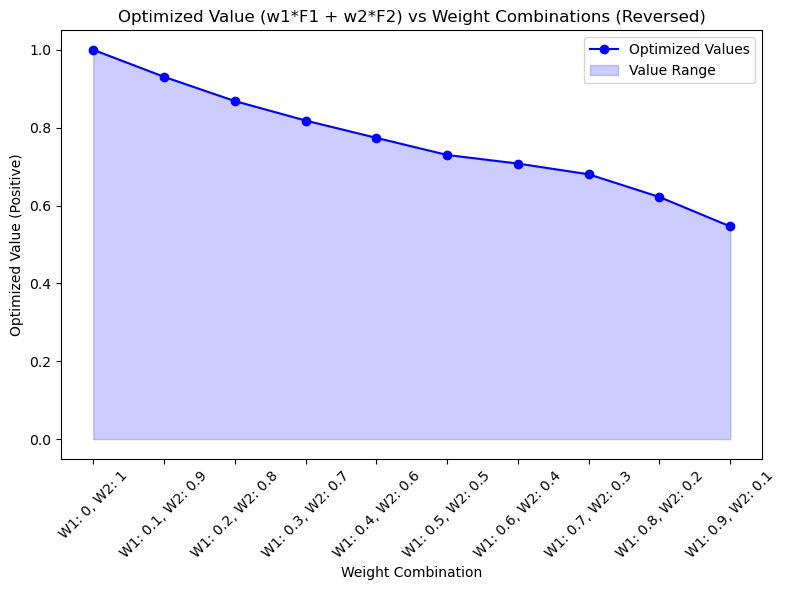

In [33]:
# 将负数值转换为正数
positive_optimized_values = [abs(value) for value in optimized_values]

# 绘制优化值与权重组合的图表
plt.figure(figsize=(8, 6))
plt.plot(weight_labels, positive_optimized_values, marker='o', linestyle='-', color='b', label='Optimized Values')

# 添加阴影
plt.fill_between(
    weight_labels,
    [0] * len(positive_optimized_values),
    positive_optimized_values,
    color='blue',
    alpha=0.2,
    label='Value Range'
)

# 设置标题和轴标签
plt.title("Optimized Value (w1*F1 + w2*F2) vs Weight Combinations (Reversed)")
plt.xlabel("Weight Combination")
plt.ylabel("Optimized Value (Positive)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


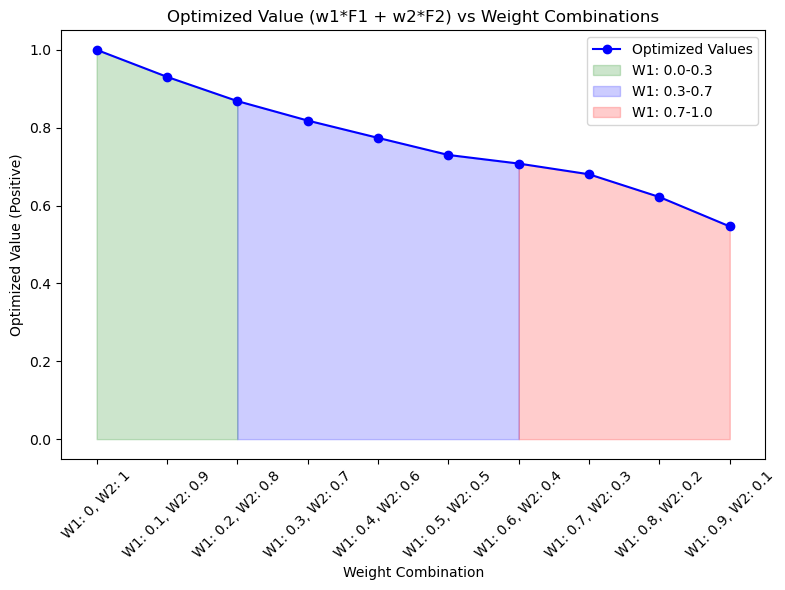

In [34]:
# 将负数值转换为正数
positive_optimized_values = [abs(value) for value in optimized_values]

# 创建权重范围的映射
weight_ranges = [w1 for w1, _ in weight_combinations]

# 绘制优化值与权重组合的图表
plt.figure(figsize=(8, 6))
plt.plot(weight_labels, positive_optimized_values, marker='o', linestyle='-', color='b', label='Optimized Values')

# 绘制整块阴影
# W1: 0.0-0.25 -> 浅红色
plt.fill_between(
    range(3),  # 区间 W1: 0.0-0.25 (用索引表示)
    [0] * 3,
    positive_optimized_values[:3],
    color='green',
    alpha=0.2,
    label='W1: 0.0-0.3',
)

# W1: 0.25-0.75 -> 蓝色
plt.fill_between(
    range(2, 7),  # 区间 W1: 0.25-0.75
    [0] * 5,
    positive_optimized_values[2:7],
    color='blue',
    alpha=0.2,
    label='W1: 0.3-0.7',
)

# W1: 0.75-1.0 -> 浅绿色
plt.fill_between(
    range(6, len(weight_labels)),  # 区间 W1: 0.75-1.0
    [0] * (len(weight_labels) - 6),
    positive_optimized_values[6:],
    color='red',
    alpha=0.2,
    label='W1: 0.7-1.0',
)

# 去掉两边多余的空白
plt.margins(x=0)  # 将 x 轴边距设置为 0
plt.gca().set_xlim(-0.5, len(weight_labels) - 0.5)  # 调整 x 轴的显示范围

# 设置标题和轴标签
plt.title("Optimized Value (w1*F1 + w2*F2) vs Weight Combinations")
plt.xlabel("Weight Combination")
plt.ylabel("Optimized Value (Positive)")
plt.xticks(range(len(weight_labels)), weight_labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
! pip install pymoo

In [10]:
pip install -U pymoo


Note: you may need to restart the kernel to use updated packages.
